In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [ ]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [7]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:05<00:00, 196.95it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [ ]:
batch_size = 64
beta = 0.31
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
mse = MeanSquaredError()
mse = mse.to(device)

In [11]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [12]:
event_train = events_train[:SELECTED_EVENTS][0]

In [13]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [15]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [16]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [17]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [18]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [19]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        residual_slope: float = 0.08
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        z_encoded = self.encoder(x)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [ ]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 243.76it/s, Loss (BCE + VQ)=0.0547]


Epoch [1/80] summary:Average Loss: VQ + BCE = 0.1976,  Average loss: BCE = 0.0727 MSE = 0.008875368691831078 avg_perplexity = 5.263185540635382
Average validation set BCE loss: 0.05343922004103661
Before compression (Training)
Shape: (13, 8, 8)


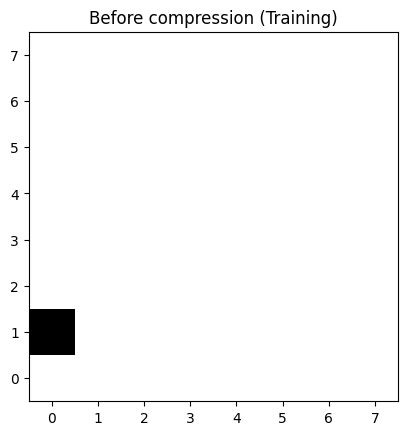

After compression (Training)
Shape: (1, 8, 8)


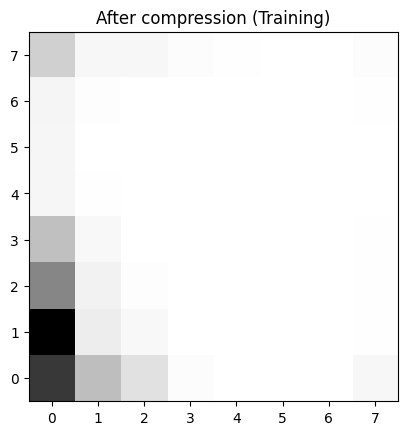

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 319.28it/s, Loss (BCE + VQ)=0.0499]


Epoch [2/80] summary:Average Loss: VQ + BCE = 0.0553,  Average loss: BCE = 0.0483 MSE = 0.005038611370901666 avg_perplexity = 19.155512685152754
Average validation set BCE loss: 0.04321078434586525


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 318.25it/s, Loss (BCE + VQ)=0.0568]


Epoch [3/80] summary:Average Loss: VQ + BCE = 0.0472,  Average loss: BCE = 0.0429 MSE = 0.004091296354355524 avg_perplexity = 31.444806592548314
Average validation set BCE loss: 0.04076503068208694


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 275.85it/s, Loss (BCE + VQ)=0.0499]


...

Epoch [14/80] summary:Average Loss: VQ + BCE = 0.0355,  Average loss: BCE = 0.0337 MSE = 0.002373935803349818 avg_perplexity = 94.99846033834332
Average validation set BCE loss: 0.03386052548885345


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 330.06it/s, Loss (BCE + VQ)=0.0288]


Epoch [15/80] summary:Average Loss: VQ + BCE = 0.0352,  Average loss: BCE = 0.0334 MSE = 0.002331030991480653 avg_perplexity = 98.61266923070554
Average validation set BCE loss: 0.03372309692203999


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 328.61it/s, Loss (BCE + VQ)=0.0374]


Epoch [16/80] summary:Average Loss: VQ + BCE = 0.0350,  Average loss: BCE = 0.0332 MSE = 0.0022888624848769836 avg_perplexity = 99.19332224400199
Average validation set BCE loss: 0.033491334319114684
Before compression (Training)
Shape: (13, 8, 8)


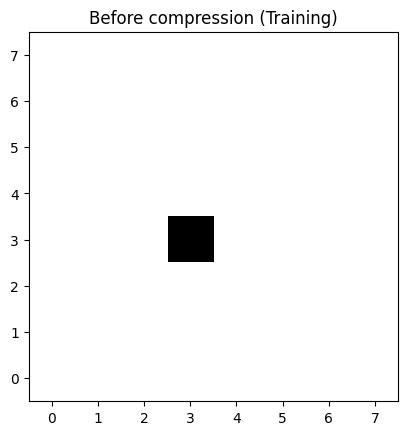

After compression (Training)
Shape: (1, 8, 8)


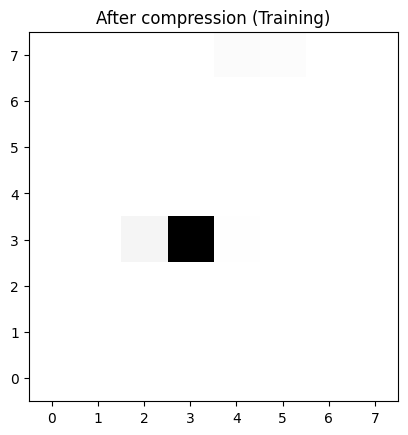

Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 299.39it/s, Loss (BCE + VQ)=0.0277]


Epoch [17/80] summary:Average Loss: VQ + BCE = 0.0346,  Average loss: BCE = 0.0329 MSE = 0.002235621326818276 avg_perplexity = 100.09792544494323
Average validation set BCE loss: 0.033847749978303907


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 331.33it/s, Loss (BCE + VQ)=0.033] 


Epoch [18/80] summary:Average Loss: VQ + BCE = 0.0344,  Average loss: BCE = 0.0327 MSE = 0.002183196750871987 avg_perplexity = 101.59341904146588
Average validation set BCE loss: 0.0338072843849659


Epoch 19/80: 100%|██████████| 199/199 [00:00<00:00, 365.30it/s, Loss (BCE + VQ)=0.0273]


...

Epoch [29/80] summary:Average Loss: VQ + BCE = 0.0327,  Average loss: BCE = 0.0312 MSE = 0.001867249672097533 avg_perplexity = 106.65896813474109
Average validation set BCE loss: 0.03292874507606029


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 369.54it/s, Loss (BCE + VQ)=0.0454]


Epoch [30/80] summary:Average Loss: VQ + BCE = 0.0327,  Average loss: BCE = 0.0312 MSE = 0.0018452965273011719 avg_perplexity = 107.0887004334723
Average validation set BCE loss: 0.03326279670000076


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 351.29it/s, Loss (BCE + VQ)=0.0344]


Epoch [31/80] summary:Average Loss: VQ + BCE = 0.0327,  Average loss: BCE = 0.0312 MSE = 0.0018475693363892898 avg_perplexity = 107.5966591188057
Average validation set BCE loss: 0.03257566764950752
Before compression (Training)
Shape: (13, 8, 8)


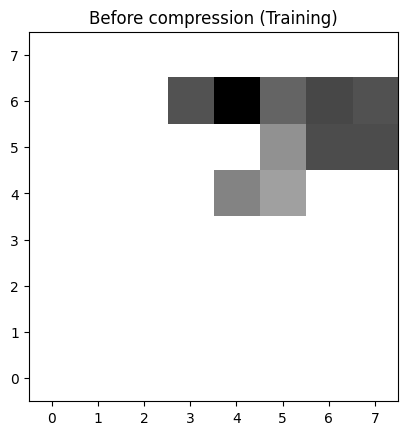

After compression (Training)
Shape: (1, 8, 8)


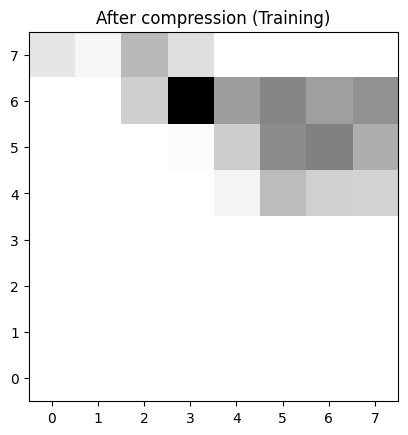

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 330.20it/s, Loss (BCE + VQ)=0.034] 


Epoch [32/80] summary:Average Loss: VQ + BCE = 0.0326,  Average loss: BCE = 0.0311 MSE = 0.0018185268102995302 avg_perplexity = 107.59862844189207
Average validation set BCE loss: 0.032505540549755095


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 300.42it/s, Loss (BCE + VQ)=0.0357]


Epoch [33/80] summary:Average Loss: VQ + BCE = 0.0324,  Average loss: BCE = 0.0309 MSE = 0.0017773686447789209 avg_perplexity = 108.54850772876836
Average validation set BCE loss: 0.032140087336301804


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 305.10it/s, Loss (BCE + VQ)=0.0232]


...

Epoch [44/80] summary:Average Loss: VQ + BCE = 0.0315,  Average loss: BCE = 0.0302 MSE = 0.001571623134618653 avg_perplexity = 112.34858724699548
Average validation set BCE loss: 0.03225936517119408


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 329.02it/s, Loss (BCE + VQ)=0.0266]


Epoch [45/80] summary:Average Loss: VQ + BCE = 0.0313,  Average loss: BCE = 0.0300 MSE = 0.0015351344593192203 avg_perplexity = 112.05532177489007
Average validation set BCE loss: 0.032322530448436734


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 329.41it/s, Loss (BCE + VQ)=0.0326]


Epoch [46/80] summary:Average Loss: VQ + BCE = 0.0314,  Average loss: BCE = 0.0300 MSE = 0.0015325725462343824 avg_perplexity = 112.3053657110013
Average validation set BCE loss: 0.032207144796848296
Before compression (Training)
Shape: (13, 8, 8)


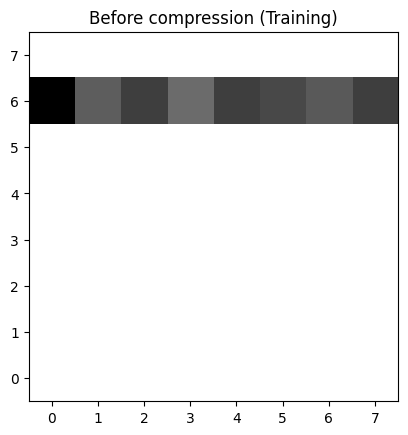

After compression (Training)
Shape: (1, 8, 8)


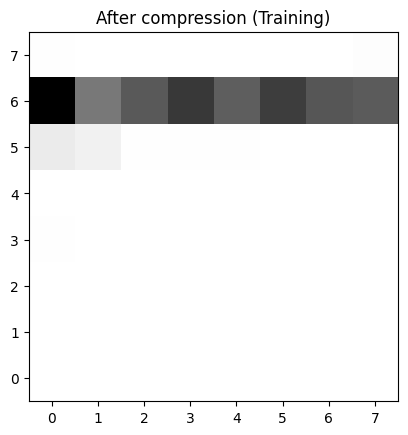

Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 297.30it/s, Loss (BCE + VQ)=0.042] 


Epoch [47/80] summary:Average Loss: VQ + BCE = 0.0313,  Average loss: BCE = 0.0300 MSE = 0.0015160545967659684 avg_perplexity = 112.53702940054275
Average validation set BCE loss: 0.03226949572563172


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 332.32it/s, Loss (BCE + VQ)=0.0367]


Epoch [48/80] summary:Average Loss: VQ + BCE = 0.0312,  Average loss: BCE = 0.0299 MSE = 0.0014956305479167506 avg_perplexity = 112.43311614606847
Average validation set BCE loss: 0.032007965818047525


Epoch 49/80: 100%|██████████| 199/199 [00:00<00:00, 362.72it/s, Loss (BCE + VQ)=0.0334]


...

Epoch [59/80] summary:Average Loss: VQ + BCE = 0.0306,  Average loss: BCE = 0.0294 MSE = 0.0013325765056783642 avg_perplexity = 113.17013007312563
Average validation set BCE loss: 0.0325149230659008


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 316.52it/s, Loss (BCE + VQ)=0.0242]


Epoch [60/80] summary:Average Loss: VQ + BCE = 0.0306,  Average loss: BCE = 0.0293 MSE = 0.001332395747783664 avg_perplexity = 112.63267925396636
Average validation set BCE loss: 0.03192673809826374


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 313.90it/s, Loss (BCE + VQ)=0.0318]


Epoch [61/80] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0292 MSE = 0.001289311749334143 avg_perplexity = 113.31649705513038
Average validation set BCE loss: 0.032849835231900215
Before compression (Training)
Shape: (13, 8, 8)


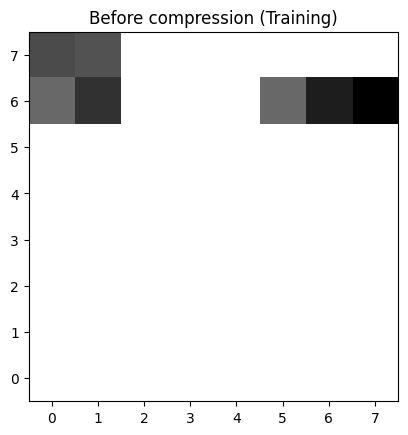

After compression (Training)
Shape: (1, 8, 8)


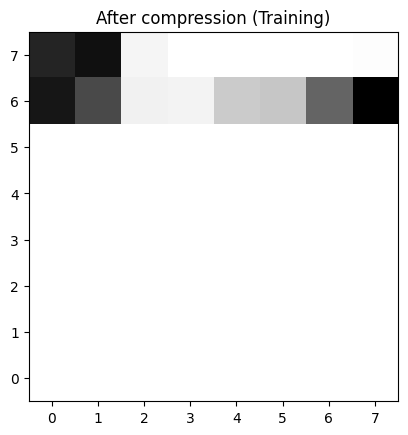

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 303.40it/s, Loss (BCE + VQ)=0.0329]


Epoch [62/80] summary:Average Loss: VQ + BCE = 0.0306,  Average loss: BCE = 0.0293 MSE = 0.0013192198873993627 avg_perplexity = 113.31640809025596
Average validation set BCE loss: 0.03181141689419746


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 328.28it/s, Loss (BCE + VQ)=0.0374]


Epoch [63/80] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0293 MSE = 0.0013088893265833133 avg_perplexity = 113.26169649440439
Average validation set BCE loss: 0.03180721551179886


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 331.77it/s, Loss (BCE + VQ)=0.0311]


...

Epoch [74/80] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0288 MSE = 0.0011631069019268356 avg_perplexity = 114.43902076069435
Average validation set BCE loss: 0.03210077472031116


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 363.80it/s, Loss (BCE + VQ)=0.0227]


Epoch [75/80] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0287 MSE = 0.0011469608183889346 avg_perplexity = 114.6236120827833
Average validation set BCE loss: 0.032450710982084276


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 331.07it/s, Loss (BCE + VQ)=0.0362]


Epoch [76/80] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0287 MSE = 0.001130576875825979 avg_perplexity = 114.58524794075358
Average validation set BCE loss: 0.032015522196888926
Before compression (Training)
Shape: (13, 8, 8)


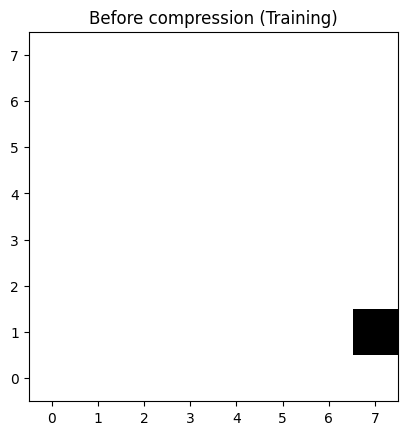

After compression (Training)
Shape: (1, 8, 8)


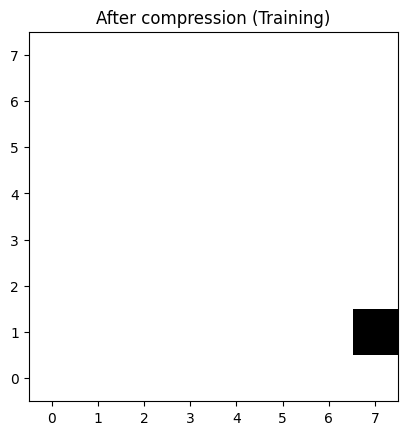

Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 236.69it/s, Loss (BCE + VQ)=0.0327]


Epoch [77/80] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0287 MSE = 0.0011390508023844143 avg_perplexity = 114.58442323770954
Average validation set BCE loss: 0.03212839737534523


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 258.20it/s, Loss (BCE + VQ)=0.0214]


Epoch [78/80] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0286 MSE = 0.001106689874511025 avg_perplexity = 114.66729836008656
Average validation set BCE loss: 0.032312994822859764


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 240.66it/s, Loss (BCE + VQ)=0.0236]


Epoch [79/80] summary:Average Loss: VQ + BCE = 0.0296,  Average loss: BCE = 0.0285 MSE = 0.0010810823732022965 avg_perplexity = 114.53775773934983
Average validation set BCE loss: 0.03231198489665985


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 301.71it/s, Loss (BCE + VQ)=0.0341]


Epoch [80/80] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0286 MSE = 0.0010863330233350733 avg_perplexity = 114.33793640136719
Average validation set BCE loss: 0.03250160627067089
Before compression (Validation)
Shape: (64, 8, 8)


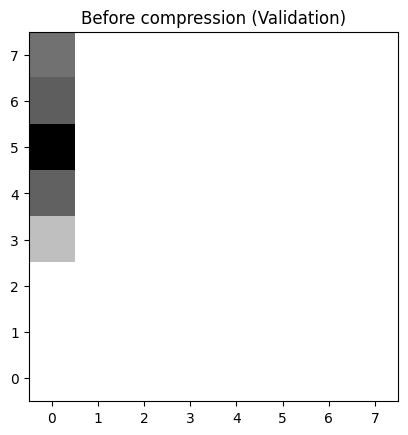

After compression (Validation)
Shape: (1, 8, 8)


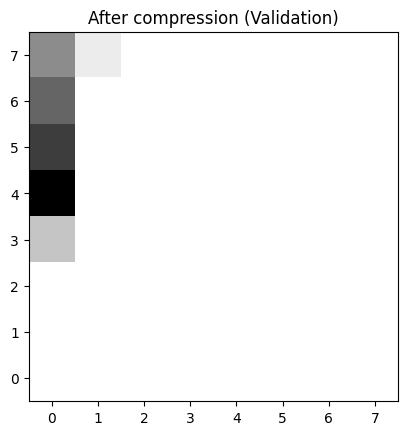

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


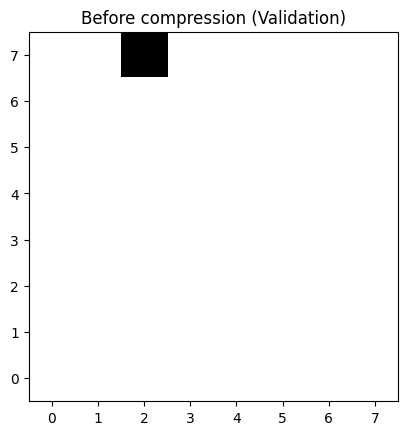

After compression (Validation)
Shape: (1, 8, 8)


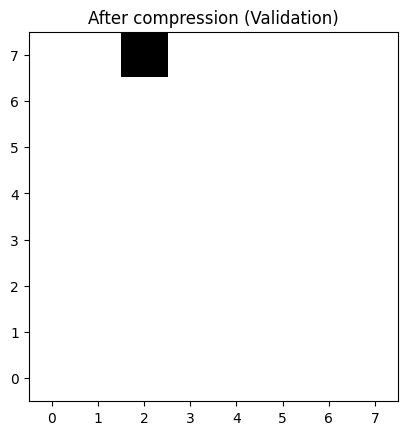

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


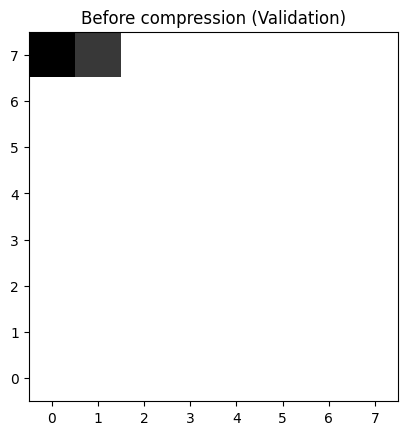

After compression (Validation)
Shape: (1, 8, 8)


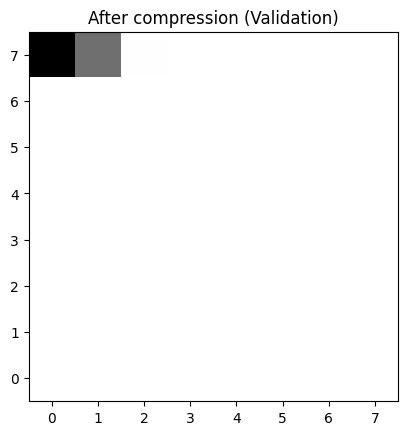

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


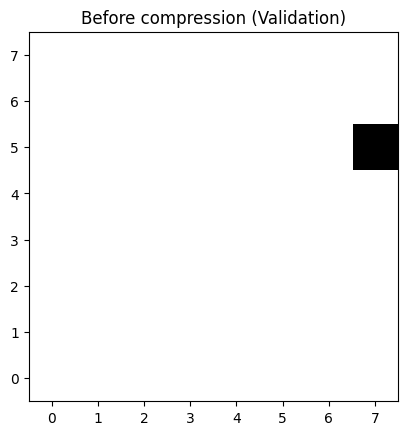

After compression (Validation)
Shape: (1, 8, 8)


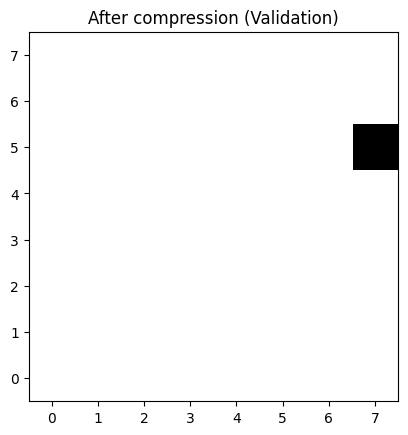

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


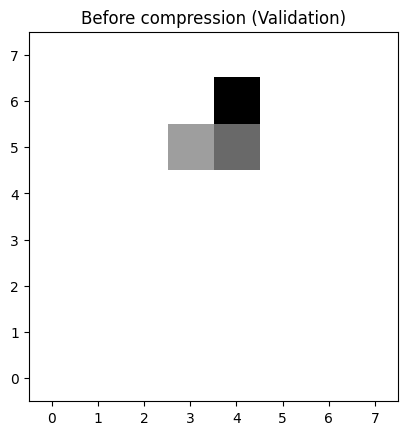

After compression (Validation)
Shape: (1, 8, 8)


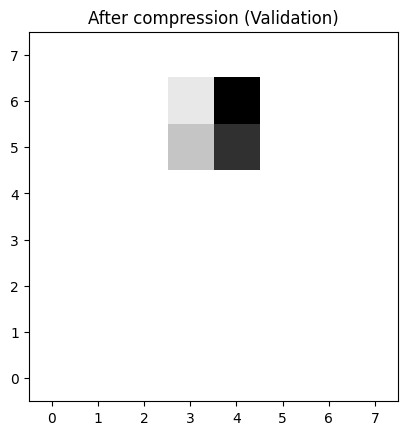

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [21]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val[0][0].shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        width_val, 
                        height_val, 
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [22]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


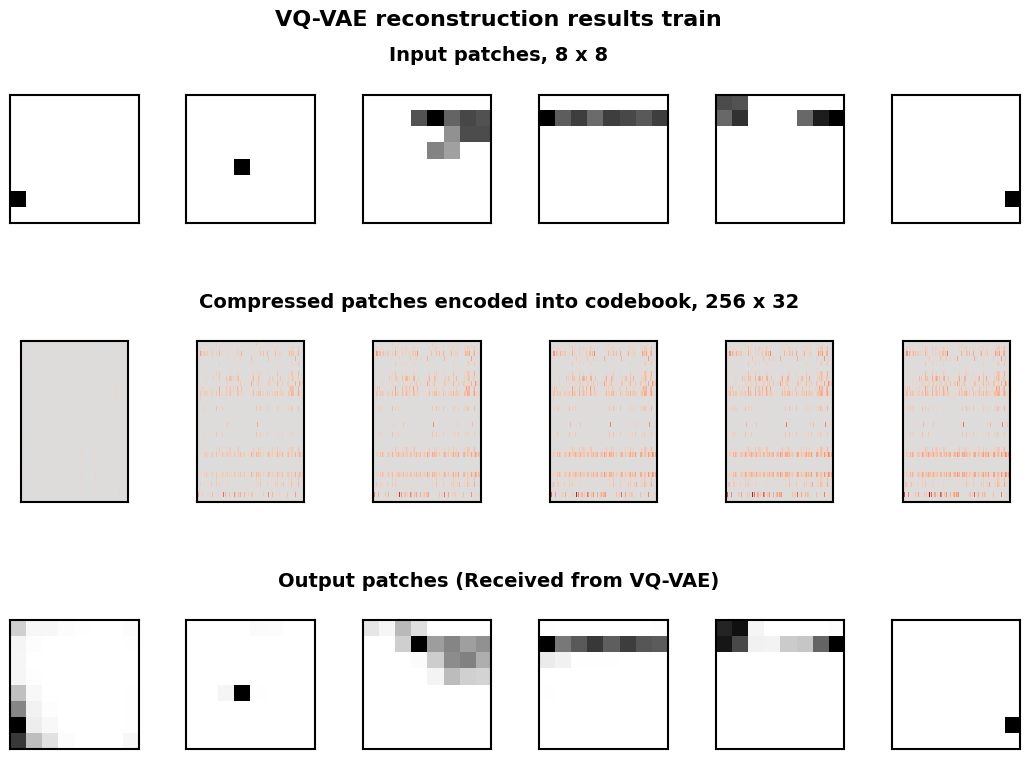

In [23]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

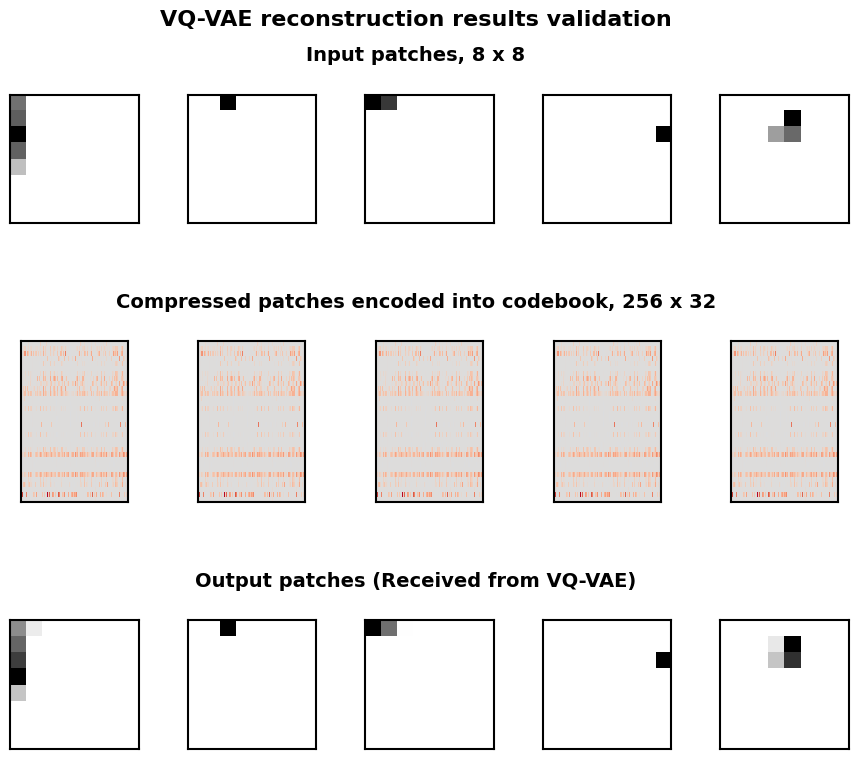

In [24]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [25]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.02071782574057579
encoder.1.weight 0.001499653561040759
encoder.1.bias 0.0018549859523773193
encoder.3.weight 0.025991294533014297
encoder.4.weight 0.0013039972400292754
encoder.4.bias 0.0011685686185956001
encoder.6.weight 0.032216716557741165
encoder.7.weight 0.0028334276285022497
encoder.7.bias 0.0027125875931233168
encoder.8.stack.0.res_block.1.weight 0.006188030820339918
encoder.8.stack.0.res_block.3.weight 0.00509730214253068
encoder.8.stack.1.res_block.1.weight 0.008317102678120136
encoder.8.stack.1.res_block.3.weight 0.007066918537020683
vq_layer.embedding.weight 0.00044517923379316926
decoder.0.weight 0.01552742999047041
decoder.1.weight 0.0016359665896743536
decoder.1.bias 0.0013684654841199517
decoder.2.stack.0.res_block.1.weight 0.004861438646912575
decoder.2.stack.0.res_block.3.weight 0.005354645196348429
decoder.2.stack.1.res_block.1.weight 0.004076128825545311
decoder.2.stack.1.res_block.3.weight 0.0037913573905825615
decoder.3.

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


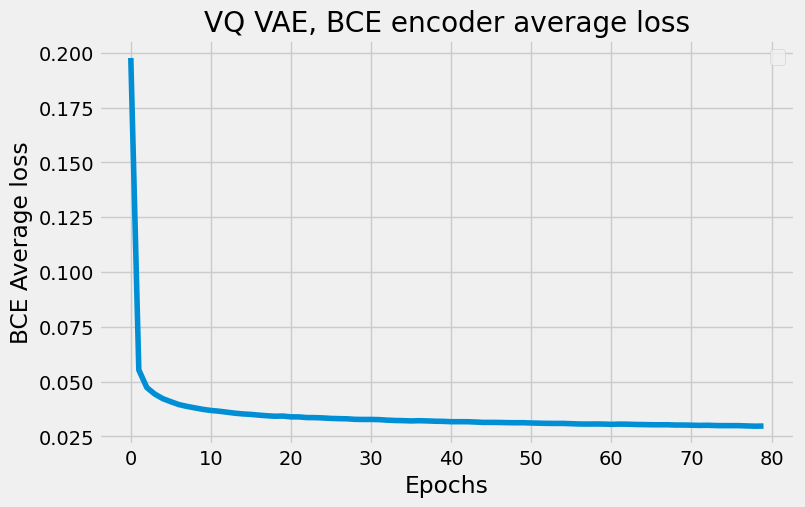

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [26]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [27]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.13445
Based on test set (size = 45), average codebook perplexity = 97.50252/256
Saved VQ-VAE test results


In [28]:
len(patches_before_test)

6

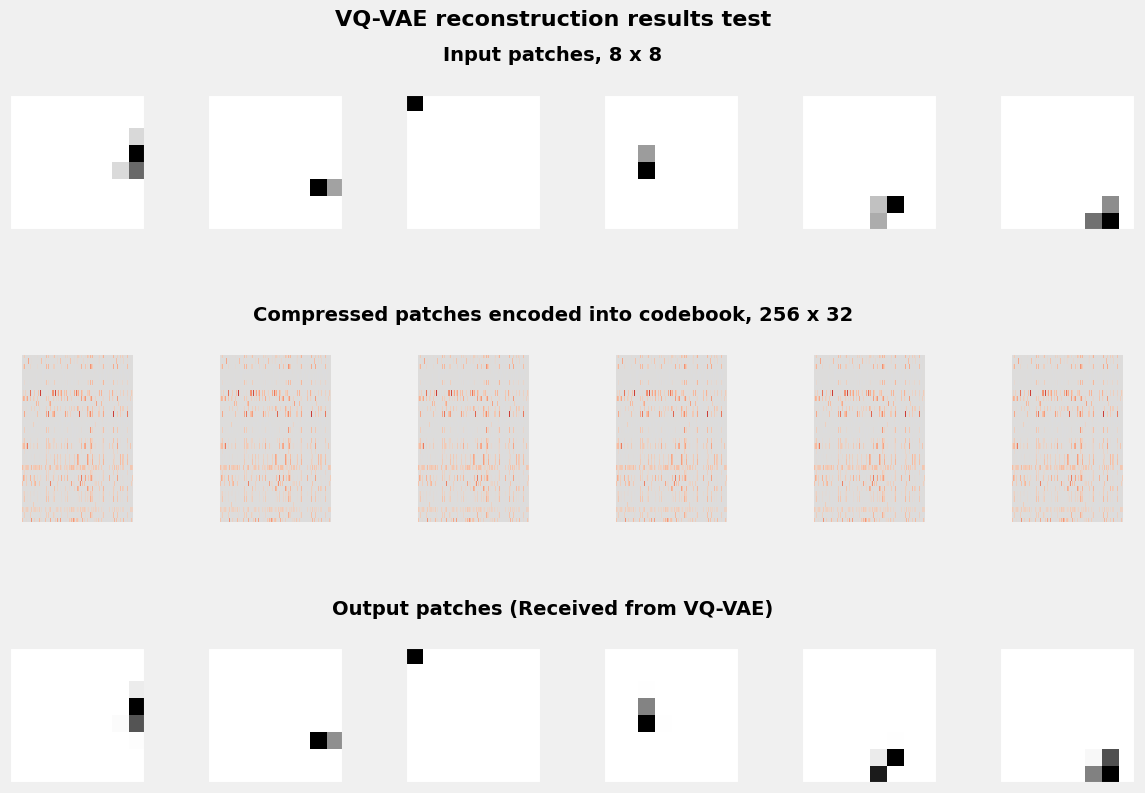

In [29]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

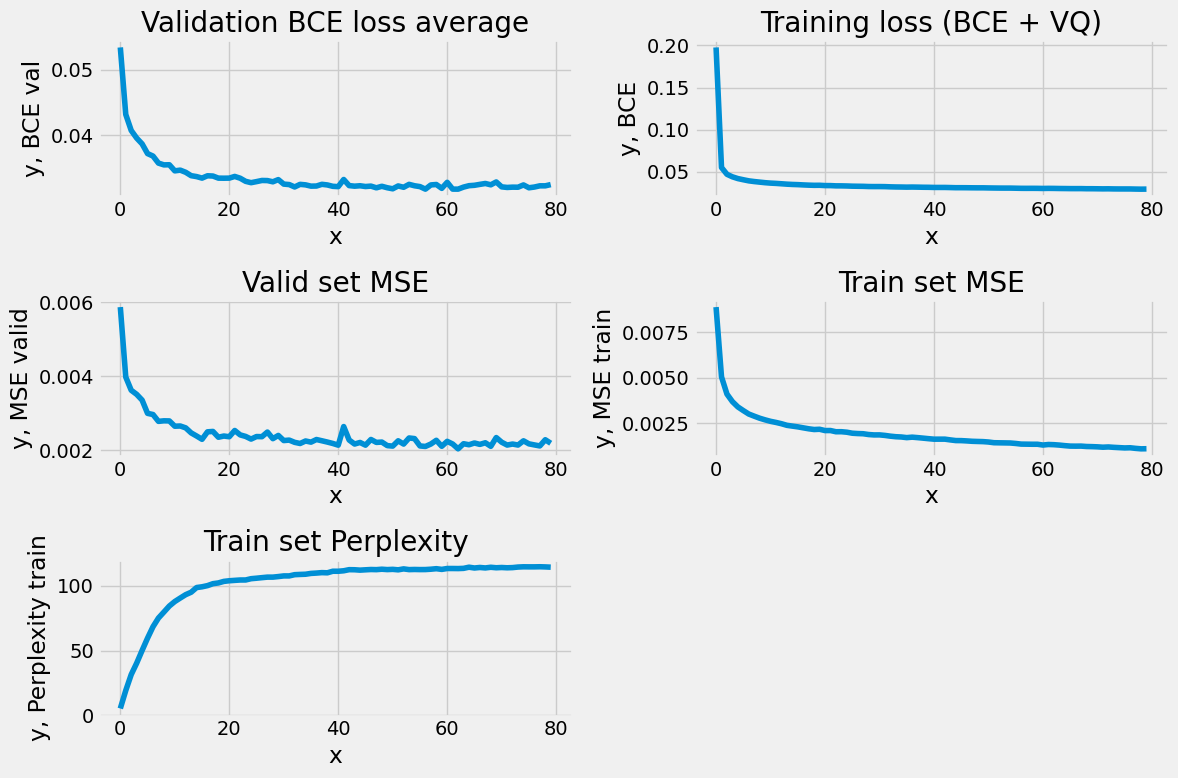

In [30]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)
